# ML Project - Random Forest
## Hotel Cancellation Prediction Analysis
### Part 1: Data Exploration & Pre-processing
### Part 2: Model Building

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, classification_report, confusion_matrix)

# 1) Load Dataset

cd C:\Users\rjban\Desktop\ml\ML Projects

In [14]:
df = pd.read_csv("ML Project - Random Forest Hotel Cancellation Prediction Analysis.txt")

In [15]:
df.head(2)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,01/07/2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,01/07/2015


# 2) Print Unique Values in All Columns

In [16]:
for col in df.columns:
    print(f"{col} : {df[col].nunique()} unique values")

hotel : 1 unique values
is_canceled : 2 unique values
lead_time : 411 unique values
arrival_date_year : 3 unique values
arrival_date_month : 12 unique values
arrival_date_week_number : 53 unique values
arrival_date_day_of_month : 31 unique values
stays_in_weekend_nights : 16 unique values
stays_in_week_nights : 31 unique values
adults : 14 unique values
children : 5 unique values
babies : 3 unique values
meal : 5 unique values
country : 125 unique values
market_segment : 6 unique values
distribution_channel : 4 unique values
is_repeated_guest : 2 unique values
previous_cancellations : 11 unique values
previous_bookings_not_canceled : 31 unique values
reserved_room_type : 10 unique values
assigned_room_type : 11 unique values
booking_changes : 15 unique values
deposit_type : 3 unique values
agent : 184 unique values
company : 235 unique values
days_in_waiting_list : 44 unique values
customer_type : 4 unique values
adr : 5533 unique values
required_car_parking_spaces : 5 unique values
to

# 3) Fill NaN with 'other'

In [17]:
df = df.fillna('other')

# 4) Fill NaN in agent with mean

In [19]:
df["agent"] = pd.to_numeric(df["agent"], errors="coerce")
df["agent"].fillna(df["agent"].mean(), inplace=True)

C:\Users\rjban\AppData\Local\Temp\ipykernel_9904\2796441451.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["agent"].fillna(df["agent"].mean(), inplace=True)


# 5) Drop Remaining Null Values

In [20]:
df.dropna(inplace=True)
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

# 6) Bar Plot of Adults and Children

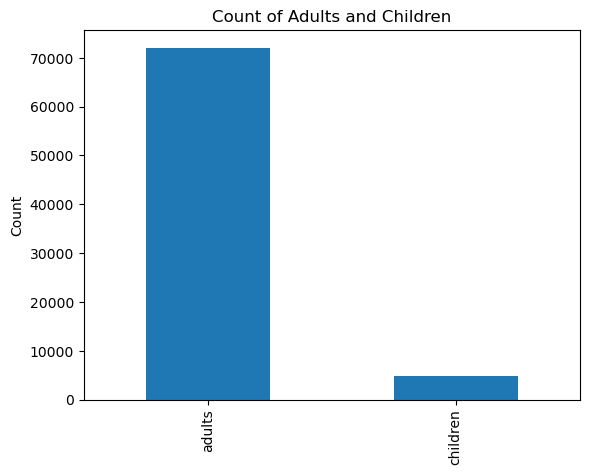

In [21]:
plt.figure()
df[["adults", "children"]].sum().plot(kind="bar")
plt.title("Count of Adults and Children")
plt.ylabel("Count")
plt.show()

# 7) Label Encoding

In [25]:
df["agent"] = pd.to_numeric(df["agent"], errors="coerce")
df["agent"].fillna(df["agent"].mean(), inplace=True)

C:\Users\rjban\AppData\Local\Temp\ipykernel_9904\2796441451.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["agent"].fillna(df["agent"].mean(), inplace=True)


In [29]:
for col in df.select_dtypes(include=["object"]).columns:
    df[col].fillna("other", inplace=True)

In [30]:
df.dropna(inplace=True)

In [31]:
le = LabelEncoder()

In [32]:
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str)   
    df[col] = le.fit_transform(df[col])

# Part 2: Model Building

# 1) Create Features and Target

In [36]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# 2) Train-Test Split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3) Apply Random Forest

In [39]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# 4) Evaluation Function

In [40]:
def evaluate_model(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
evaluate_model(y_test, y_pred)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5567
           1       1.00      1.00      1.00      2181

    accuracy                           1.00      7748
   macro avg       1.00      1.00      1.00      7748
weighted avg       1.00      1.00      1.00      7748

nConfusion Matrix:
[[5567    0]
 [   0 2181]]
